라이브러리 설치

In [1]:
!pip install numpy pandas

In [2]:
!pip install aeon

In [3]:
!pip install scikit-learn

In [4]:
!pip install matplotlib seaborn

In [5]:
!pip install tensorflow

라이브러리 임포트

In [6]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

데이터 로드

In [7]:
from aeon.datasets import load_classification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc

In [8]:
X, y = load_classification(name="FordA")

print(f"Train Data Shape: {X.shape}")
print(f"Test Data Shape: {y.shape}")

C:\Users\nyank\AppData\Local\Temp\ipykernel_19832\162285114.py:1: FutureWarning: Call to deprecated function (or staticmethod) load_classification. (load_classification parameters load_equal_length and load_no_missing will default to False in version 1.5.0) -- Deprecated since version 1.4.0.
  X, y = load_classification(name="FordA")


Train Data Shape: (4921, 1, 500)
Test Data Shape: (4921,)


In [9]:
#타겟 클래스 변환
y = pd.Series(y).map({'1': 'Defect', '-1': 'Normal'}).values

----------------------------------------
 Class  Count  Percentage
Defect   2394   48.648649
Normal   2527   51.351351
----------------------------------------


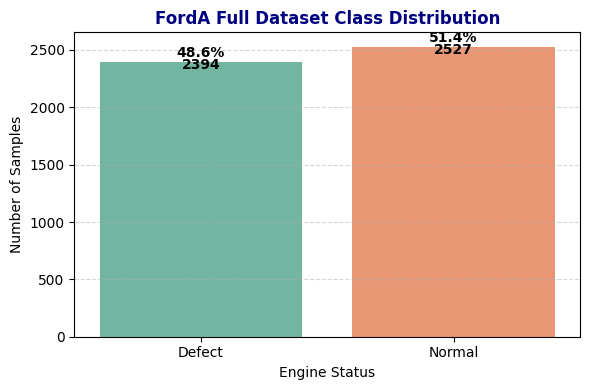

In [ ]:
unique, counts = np.unique(y, return_counts=True)
class_dist = pd.DataFrame({'Class': unique, 'Count': counts})
class_dist['Percentage'] = (class_dist['Count'] / class_dist['Count'].sum()) * 100

print("-" * 40)
print(class_dist.to_string(index=False))
print("-" * 40)

plt.figure(figsize=(6, 4))
sns.barplot(data=class_dist, x='Class', y='Count', palette='Set2', hue='Class', legend=False)
plt.title("FordA Full Dataset Class Distribution", fontsize=12, fontweight='bold', color='navy')
plt.xlabel("Engine Status")
plt.ylabel("Number of Samples")
plt.grid(axis='y', linestyle='--', alpha=0.5)

for p in class_dist.index:
    count = class_dist.loc[p, 'Count']
    percent = class_dist.loc[p, 'Percentage']
    plt.text(p, count + 40, f'{percent:.1f}%', ha="center", fontsize=10, fontweight='bold')
    plt.text(p, count - 60, f'{count}', ha="center", fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("image/dataClassDistribution.png")
plt.show()

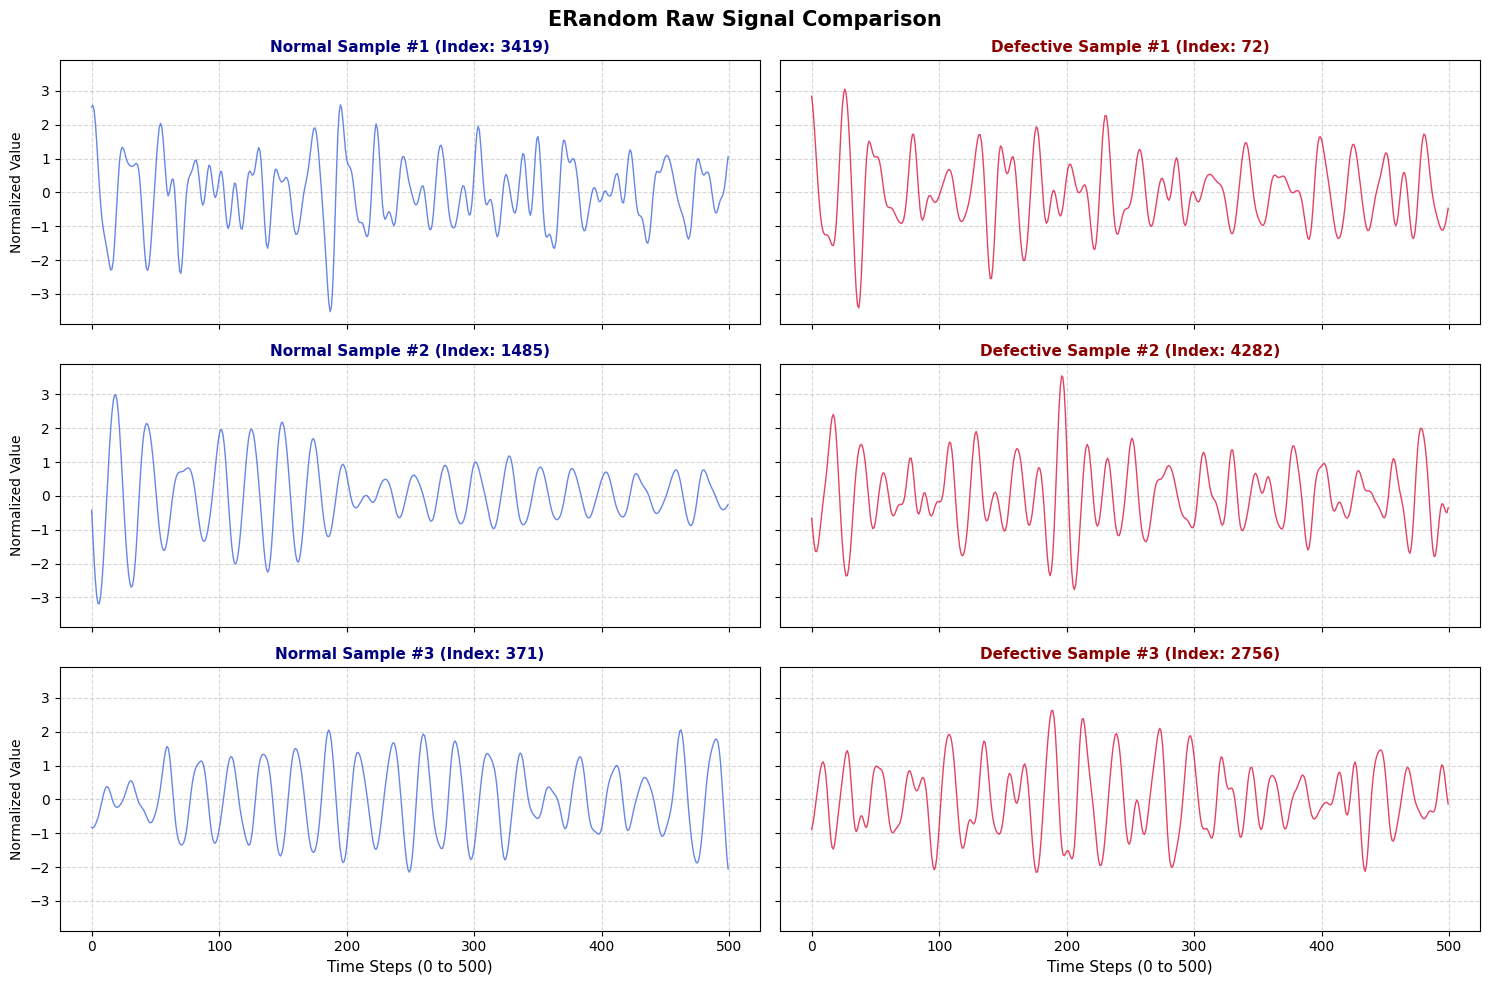

In [ ]:
import random

np.random.seed(42)
normal_indices = np.where(y == 'Normal')[0]
defect_indices = np.where(y == 'Defect')[0]

random_normal_idx = np.random.choice(normal_indices, 3, replace=False)
random_defect_idx = np.random.choice(defect_indices, 3, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(15, 10), sharex=True, sharey=True)

for i in range(3):
    n_idx = random_normal_idx[i]
    axes[i, 0].plot(X[n_idx, 0, :], color="royalblue", linewidth=1, alpha=0.8)
    axes[i, 0].set_title(f"Normal Sample #{i+1} (Index: {n_idx})", fontsize=11, fontweight='bold', color='navy')
    axes[i, 0].set_ylabel("Normalized Value")
    axes[i, 0].grid(True, linestyle="--", alpha=0.5)
    
    d_idx = random_defect_idx[i]
    axes[i, 1].plot(X[d_idx, 0, :], color="crimson", linewidth=1, alpha=0.8)
    axes[i, 1].set_title(f"Defective Sample #{i+1} (Index: {d_idx})", fontsize=11, fontweight='bold', color='darkred')
    axes[i, 1].grid(True, linestyle="--", alpha=0.5)

axes[2, 0].set_xlabel("Time Steps (0 to 500)", fontsize=11)
axes[2, 1].set_xlabel("Time Steps (0 to 500)", fontsize=11)

plt.suptitle("ERandom Raw Signal Comparison", fontsize=15, fontweight='bold', y=0.98)
plt.savefig("image/randomcomparison.png")
plt.tight_layout()
plt.show()


In [12]:
try:
    from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier
    from aeon.classification.interval_based import TimeSeriesForestClassifier
    from aeon.classification.dictionary_based import WEASEL_V2
    from aeon.classification.convolution_based import MiniRocketClassifier
    from aeon.classification.deep_learning import InceptionTimeClassifier
    from aeon.classification.shapelet_based import ShapeletTransformClassifier
    print("TSC model imported")
    
except ImportError as e:
    print("Error.")
    print(f"Error Message: {e}")

TSC model imported


In [13]:
import tensorflow as tf
print(f"GPU: {len(tf.config.list_physical_devices('GPU'))}")

GPU: 0


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,       
    random_state=42,     
    shuffle=True,    
    stratify = y
)

In [15]:
models_dict = {}


models_dict['STC'] = ShapeletTransformClassifier(
    n_shapelet_samples=5000,
    random_state=42,
    n_jobs=-1
)

models_dict['KNN_DTW'] = KNeighborsTimeSeriesClassifier(
    distance="dtw", 
    distance_params={"window":0.25},
    n_neighbors=5, 
    n_jobs=-1
)

models_dict['KNN_DTW_tuned'] = KNeighborsTimeSeriesClassifier(
    distance="dtw", 
    distance_params={"window":0.05},
    n_neighbors=7, 
    n_jobs=-1
)

models_dict['KNN_Euclidean'] = KNeighborsTimeSeriesClassifier(
    distance="euclidean", 
    n_neighbors=3, 
    n_jobs=-1
)

models_dict['TimeSeriesForest'] = TimeSeriesForestClassifier(
    n_estimators=150, 
    random_state=42, 
    n_jobs=-1
)

models_dict['WEASEL_V2'] = WEASEL_V2(
    random_state=42,
    n_jobs=-1
)

models_dict['MiniRocket'] = MiniRocketClassifier(
    random_state=42, 
    n_jobs=-1
)

models_dict['InceptionTime'] = InceptionTimeClassifier(
    n_epochs=10, 
    batch_size=64,
    random_state=42
)

In [16]:
import warnings
warnings.filterwarnings('ignore')

benchmark_results = []

print(f"{'Model Name':<20} | {'Train Time':<12} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 85)

for name, model in models_dict.items():
    try:
        start_train = time.time()
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)

        train_time = time.time() - start_train
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label='Defect', zero_division=0)
        rec = recall_score(y_test, y_pred, pos_label='Defect', zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label='Defect', zero_division=0)
        
        print(f"{name:<20} | {train_time:>10.2f}s | {acc:>9.4f} | {prec:>9.4f} | {rec:>9.4f} | {f1:>9.4f}")
        
        benchmark_results.append({
            'Model': name,
            'Train Time (sec)': round(train_time, 2),
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4),
            'y_pred': y_pred
        })
        
    except Exception as e:
        print(f"{name} error: {str(e)}")
        continue

print("-" * 85)
print("complete!!")

df_results = pd.DataFrame(benchmark_results)
df_results_sorted = df_results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

Model Name           | Train Time   | Accuracy   | Precision  | Recall     | F1-Score  
-------------------------------------------------------------------------------------
STC                  |     744.30s |    0.9336 |    0.9343 |    0.9291 |    0.9317
KNN_DTW              |     278.65s |    0.5728 |    0.5665 |    0.5216 |    0.5431
KNN_DTW_tuned        |     150.13s |    0.5938 |    0.5943 |    0.5216 |    0.5556
KNN_Euclidean        |       0.65s |    0.7102 |    0.7284 |    0.6453 |    0.6844
TimeSeriesForest     |      53.42s |    0.8328 |    0.8352 |    0.8178 |    0.8264
WEASEL_V2            |     208.98s |    0.9614 |    0.9649 |    0.9555 |    0.9602
MiniRocket           |       6.22s |    0.9404 |    0.9400 |    0.9374 |    0.9387
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step
InceptionTime        |     928.90s |    0.928

In [18]:
display(df_results_sorted.drop(columns=['y_pred']))

,Model,Train Time (sec),Accuracy,Precision,Recall,F1-Score
0,WEASEL_V2,208.98,0.9614,0.9649,0.9555,0.9602
1,MiniRocket,6.22,0.9404,0.9400,0.9374,0.9387
2,STC,744.30,0.9336,0.9343,0.9291,0.9317
3,InceptionTime,928.90,0.9289,0.8771,0.9930,0.9315
4,TimeSeriesForest,53.42,0.8328,0.8352,0.8178,0.8264
5,KNN_Euclidean,0.65,0.7102,0.7284,0.6453,0.6844
6,KNN_DTW_tuned,150.13,0.5938,0.5943,0.5216,0.5556
7,KNN_DTW,278.65,0.5728,0.5665,0.5216,0.5431


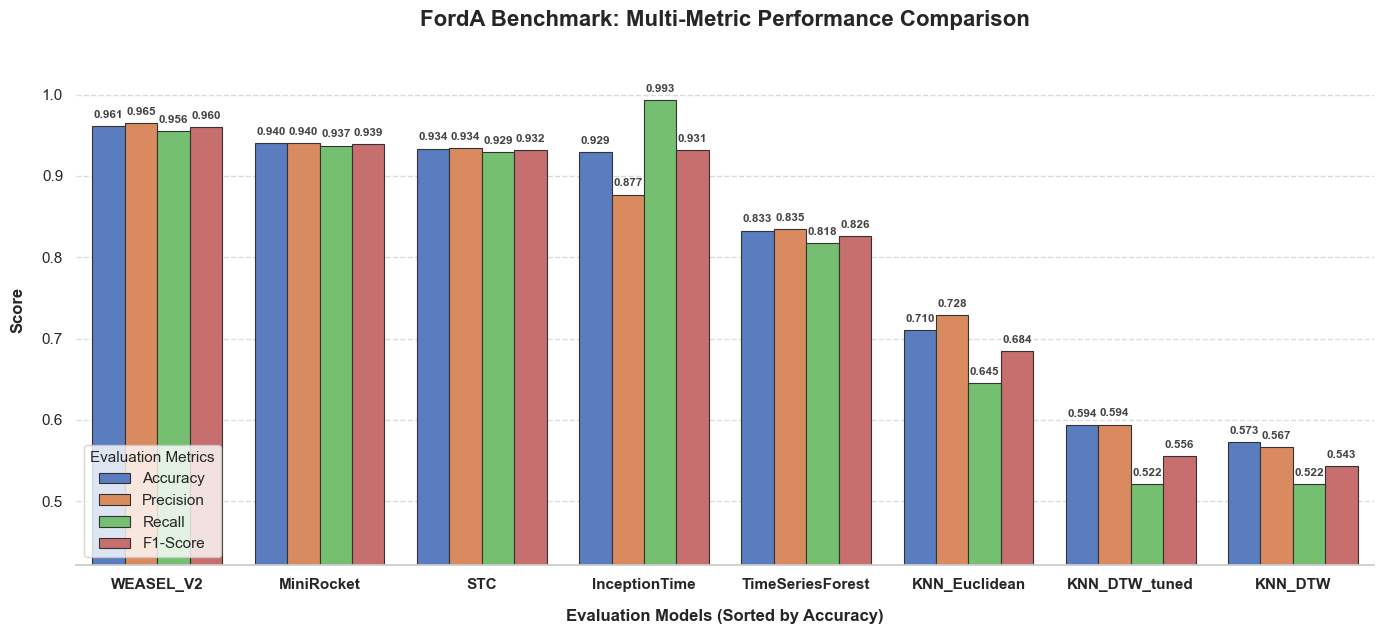

In [ ]:
sns.set_theme(style="whitegrid")

plot_df = df_results_sorted.melt(
    id_vars=['Model'], 
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(14, 6.5))

ax = sns.barplot(
    x='Model', 
    y='Score', 
    hue='Metric', 
    data=plot_df, 
    palette='muted',
    edgecolor='#333333',
    linewidth=0.8
)

for p in ax.patches:
    if p.get_height() > 0: 
        ax.annotate(
            f"{p.get_height():.3f}", 
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center', 
            xytext=(0, 8), 
            textcoords='offset points', 
            fontsize=8.5, 
            fontweight='bold', 
            color='#444444'
        )

plt.title('FordA Benchmark: Multi-Metric Performance Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Evaluation Models (Sorted by Accuracy)', fontsize=12, fontweight='bold', labelpad=12)
plt.ylabel('Score', fontsize=12, fontweight='bold', labelpad=12)

min_score = plot_df['Score'].min()
plt.ylim(max(0, min_score - 0.1), 1.05) 

plt.legend(title='Evaluation Metrics', title_fontsize='11', loc='lower left', frameon=True, facecolor='white')
plt.xticks(fontsize=11, fontweight='bold')

sns.despine(left=True, bottom=False)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("image/fordaBenchmark.png")
plt.show()

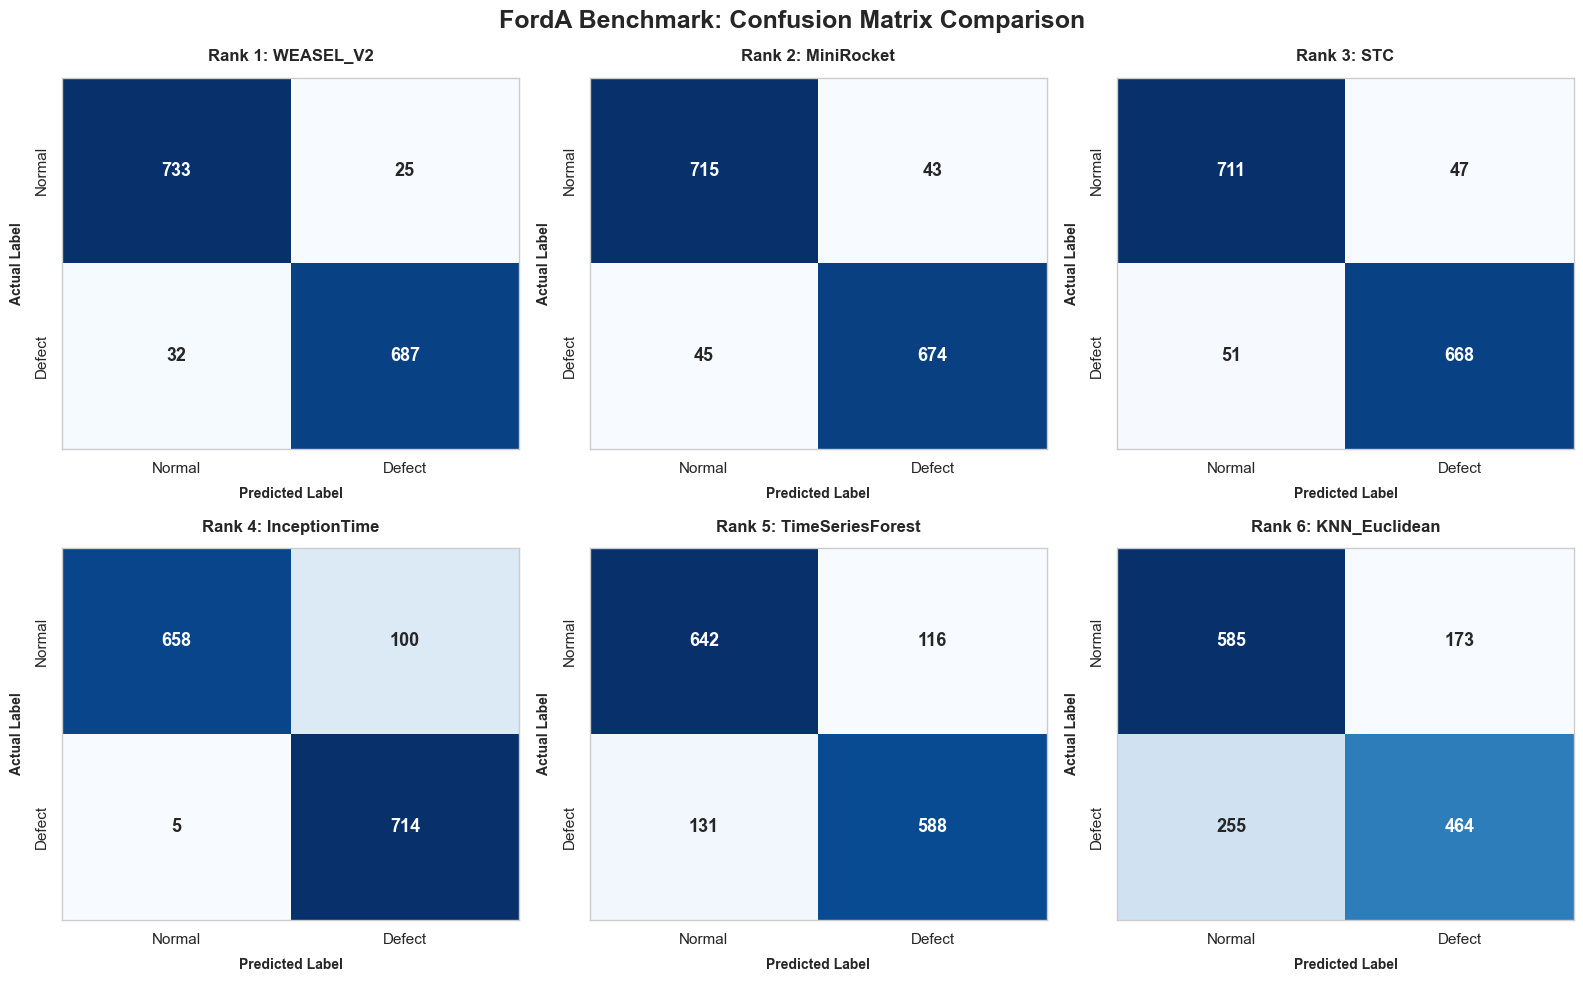

In [ ]:
from sklearn.metrics import confusion_matrix

sns.set_theme(style="white")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

labels = ['Normal', 'Defect']

for idx, row in df_results_sorted.iterrows():
    if idx >= len(axes):
        break
        
    model_name = row['Model']
    y_pred_model = row['y_pred']
    ax = axes[idx]
    
    cm = confusion_matrix(y_test, y_pred_model, labels=labels)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                cbar=False, annot_kws={"size": 13, "weight": "bold"}, ax=ax)
    
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('#cccccc')
        spine.set_linewidth(1)
        
    ax.set_title(f"Rank {idx+1}: {model_name}", 
                 fontsize=12, fontweight='bold', pad=12)
    
    # 축 라벨 설정
    ax.set_xlabel('Predicted Label', fontsize=10, fontweight='bold', labelpad=8)
    ax.set_ylabel('Actual Label', fontsize=10, fontweight='bold', labelpad=8)

for j in range(len(df_results_sorted), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('FordA Benchmark: Confusion Matrix Comparison', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("image/confusionMatrix.png")
plt.show()

In [20]:
X_fordb, y_fordb = load_classification(name="FordB")
y_fordb = pd.Series(y_fordb).map({'1': 'Defect', '-1': 'Normal'}).values

X_trainb, X_testb, y_trainb, y_testb = train_test_split(
    X_fordb, y_fordb, 
    test_size=0.3,       
    random_state=42,     
    shuffle=True,    
    stratify = y_fordb
)

In [22]:
fordb_results = []

print(f"{'Model Name':<20} | {'Inference Time':<14} | {'Accuracy (FordB)':<15} | {'F1-Score (FordB)':<15}")
print("-" * 75)

for name, model in models_dict.items():
    try:
        start_inf = time.time()
        y_pred = model.predict(X_testb)
        inf_time = time.time() - start_inf
        
        acc= accuracy_score(y_testb, y_pred)
        f1 = f1_score(y_testb, y_pred, pos_label='Defect', zero_division=0)
        
        print(f"{name:<20} | {inf_time:>12.2f}s | {acc:>15.4f} | {f1:>15.4f}")
        
        fordb_results.append({
            'Model': name,
            'Inference Time (sec)': round(inf_time, 2),
            'Accuracy': round(acc, 4),
            'F1-Score': round(f1, 4),
            'y_pred': y_pred
        })
        
    except Exception as e:
        print(f"{name} FordB Evaluation Error: {str(e)}")
        continue

print("-" * 75)
print("FordB Evaluation Complete!!")

df_fordb_results = pd.DataFrame(fordb_results)

Model Name           | Inference Time | Accuracy (FordB) | F1-Score (FordB)
---------------------------------------------------------------------------
STC                  |        94.19s |          0.8711 |          0.8711
KNN_DTW              |       270.77s |          0.6049 |          0.6150
KNN_DTW_tuned        |       118.33s |          0.6027 |          0.6086
KNN_Euclidean        |         0.54s |          0.5990 |          0.5962
TimeSeriesForest     |        12.95s |          0.7106 |          0.7211
WEASEL_V2            |        35.93s |          0.9228 |          0.9242
MiniRocket           |         0.17s |          0.8943 |          0.8970
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
InceptionTime        |         4.94s |          0.8291 |          0.8512
----------------------------------------------------------------

In [23]:
display(df_fordb_results.drop(columns=['y_pred']))

,Model,Inference Time (sec),Accuracy,F1-Score
0,STC,94.19,0.8711,0.8711
1,KNN_DTW,270.77,0.6049,0.6150
2,KNN_DTW_tuned,118.33,0.6027,0.6086
3,KNN_Euclidean,0.54,0.5990,0.5962
4,TimeSeriesForest,12.95,0.7106,0.7211
5,WEASEL_V2,35.93,0.9228,0.9242
6,MiniRocket,0.17,0.8943,0.8970
7,InceptionTime,4.94,0.8291,0.8512


***상위 3개 모델 FordB 학습***

In [24]:
models_dictb = {}


models_dictb['STC'] = ShapeletTransformClassifier(
    n_shapelet_samples=5000,
    random_state=42,
    n_jobs=-1
)

models_dictb['WEASEL_V2'] = WEASEL_V2(
    random_state=42,
    n_jobs=-1
)

models_dictb['MiniRocket'] = MiniRocketClassifier(
    random_state=42, 
    n_jobs=-1
)

In [25]:
import warnings
warnings.filterwarnings('ignore')

benchmark_results_b = []

print(f"{'Model Name':<20} | {'Train Time':<12} | {'Accuracy':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 85)

for name, model in models_dictb.items():
    try:
        start_train = time.time()
        
        model.fit(X_trainb, y_trainb)
        
        y_pred = model.predict(X_testb)

        train_time = time.time() - start_train
        
        acc = accuracy_score(y_testb, y_pred)
        prec = precision_score(y_testb, y_pred, pos_label='Defect', zero_division=0)
        rec = recall_score(y_testb, y_pred, pos_label='Defect', zero_division=0)
        f1 = f1_score(y_testb, y_pred, pos_label='Defect', zero_division=0)
        
        print(f"{name:<20} | {train_time:>10.2f}s | {acc:>9.4f} | {prec:>9.4f} | {rec:>9.4f} | {f1:>9.4f}")
        
        benchmark_results_b.append({
            'Model': name,
            'Train Time (sec)': round(train_time, 2),
            'Accuracy': round(acc, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4),
            'y_pred': y_pred
        })
        
    except Exception as e:
        print(f"{name} error: {str(e)}")
        continue

print("-" * 85)
print("complete!!")

df_results_b = pd.DataFrame(benchmark_results_b)

Model Name           | Train Time   | Accuracy   | Precision  | Recall     | F1-Score  
-------------------------------------------------------------------------------------
STC                  |     513.79s |    0.9363 |    0.9372 |    0.9329 |    0.9351
WEASEL_V2            |     157.29s |    0.9475 |    0.9439 |    0.9497 |    0.9468
MiniRocket           |       3.71s |    0.9303 |    0.9311 |    0.9268 |    0.9290
-------------------------------------------------------------------------------------
complete!!


In [27]:
display(df_results_b.drop(columns=['y_pred']))

,Model,Train Time (sec),Accuracy,Precision,Recall,F1-Score
0,STC,513.79,0.9363,0.9372,0.9329,0.9351
1,WEASEL_V2,157.29,0.9475,0.9439,0.9497,0.9468
2,MiniRocket,3.71,0.9303,0.9311,0.9268,0.9290


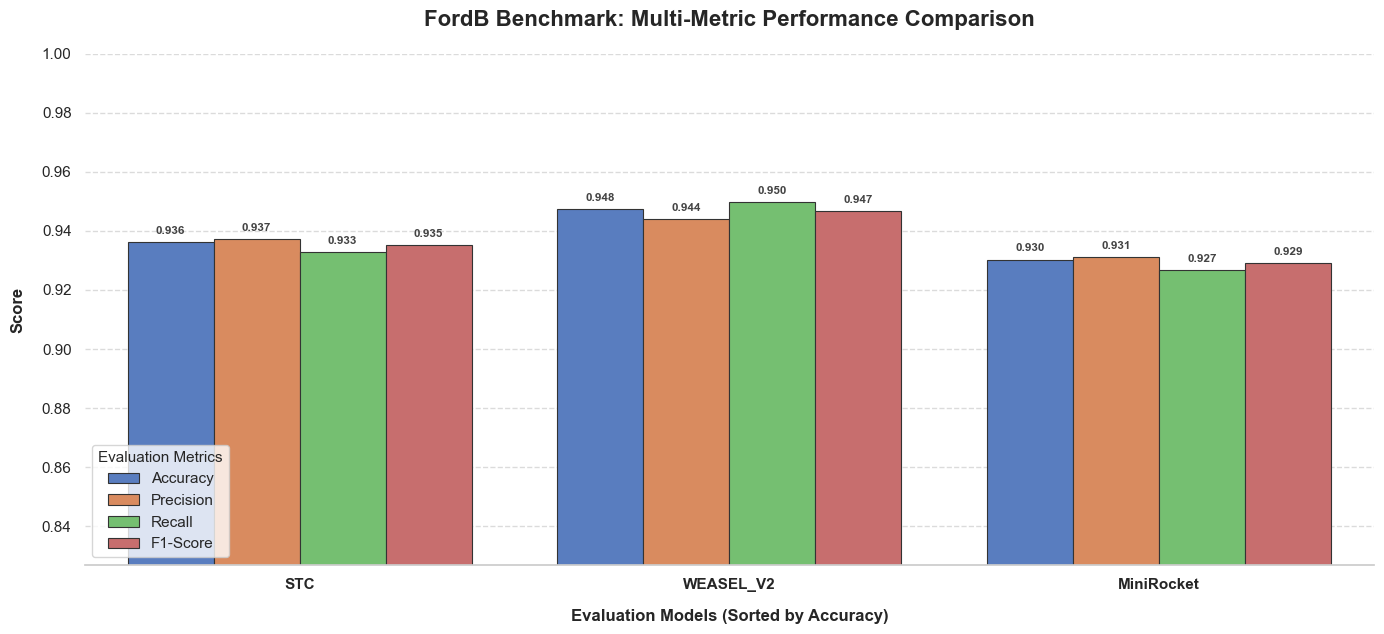

In [ ]:
sns.set_theme(style="whitegrid")

plot_df = df_results_b.melt(
    id_vars=['Model'], 
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(14, 6.5))

ax = sns.barplot(
    x='Model', 
    y='Score', 
    hue='Metric', 
    data=plot_df, 
    palette='muted',
    edgecolor='#333333',
    linewidth=0.8
)

for p in ax.patches:
    if p.get_height() > 0: 
        ax.annotate(
            f"{p.get_height():.3f}", 
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center', 
            xytext=(0, 8), 
            textcoords='offset points', 
            fontsize=8.5, 
            fontweight='bold', 
            color='#444444'
        )

plt.title('FordB Benchmark: Multi-Metric Performance Comparison', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Evaluation Models (Sorted by Accuracy)', fontsize=12, fontweight='bold', labelpad=12)
plt.ylabel('Score', fontsize=12, fontweight='bold', labelpad=12)

min_score = plot_df['Score'].min()
plt.ylim(max(0, min_score - 0.1), 1.00) 

plt.legend(title='Evaluation Metrics', title_fontsize='11', loc='lower left', frameon=True, facecolor='white')
plt.xticks(fontsize=11, fontweight='bold')

sns.despine(left=True, bottom=False)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig("image/fordbBenchmark.png")
plt.show()

In [29]:
forda_results = []

print(f"{'Model Name':<20} | {'Inference Time':<14} | {'Accuracy (FordA)':<15} | {'F1-Score (FordA)':<15}")
print("-" * 75)

for name, model in models_dictb.items():
    try:
        start_inf = time.time()
        y_pred = model.predict(X_test)
        inf_time = time.time() - start_inf
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, pos_label='Defect', zero_division=0)
        
        print(f"{name:<20} | {inf_time:>12.2f}s | {acc:>15.4f} | {f1:>15.4f}")
        
        forda_results.append({
            'Model': name,
            'Inference Time (sec)': round(inf_time, 2),
            'Accuracy': round(acc, 4),
            'F1-Score': round(f1, 4),
            'y_pred': y_pred
        })
        
    except Exception as e:
        print(f"{name} FordA Evaluation Error: {str(e)}")
        continue

print("-" * 75)
print("FordA Evaluation Complete!!")

df_forda_results = pd.DataFrame(forda_results)

Model Name           | Inference Time | Accuracy (FordA) | F1-Score (FordA)
---------------------------------------------------------------------------
STC                  |        87.44s |          0.9059 |          0.8995
WEASEL_V2            |        40.29s |          0.9181 |          0.9125
MiniRocket           |         0.18s |          0.8917 |          0.8849
---------------------------------------------------------------------------
FordA Evaluation Complete!!


In [30]:
display(df_forda_results.drop(columns=['y_pred']))

,Model,Inference Time (sec),Accuracy,F1-Score
0,STC,87.44,0.9059,0.8995
1,WEASEL_V2,40.29,0.9181,0.9125
2,MiniRocket,0.18,0.8917,0.8849


In [34]:
df_results.to_csv('result/forda_result.csv', index=False)
df_fordb_results.to_csv('result/fordatob_result.csv', index=False)
df_results_b.to_csv('result/fordb_result.csv', index=False)
df_forda_results.to_csv('result/fordbtoa_result.csv', index=False)